In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("all_data.csv")

In [4]:
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


In [9]:
df.describe()

,Year,Life expectancy at birth (years),GDP
count,96.000000,96.000000,9.600000e+01
mean,2007.500000,72.789583,3.880499e+12
std,4.633971,10.672882,5.197561e+12
min,2000.000000,44.300000,4.415703e+09
25%,2003.750000,74.475000,1.733018e+11
50%,2007.500000,76.750000,1.280220e+12
75%,2011.250000,78.900000,4.067510e+12
max,2015.000000,81.000000,1.810000e+13


<Axes: xlabel='Year'>

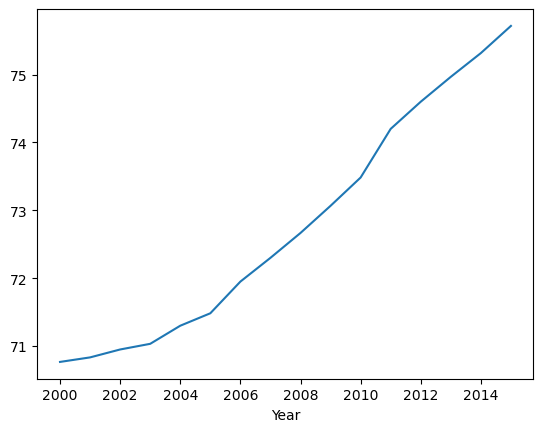

In [33]:
import numpy as np


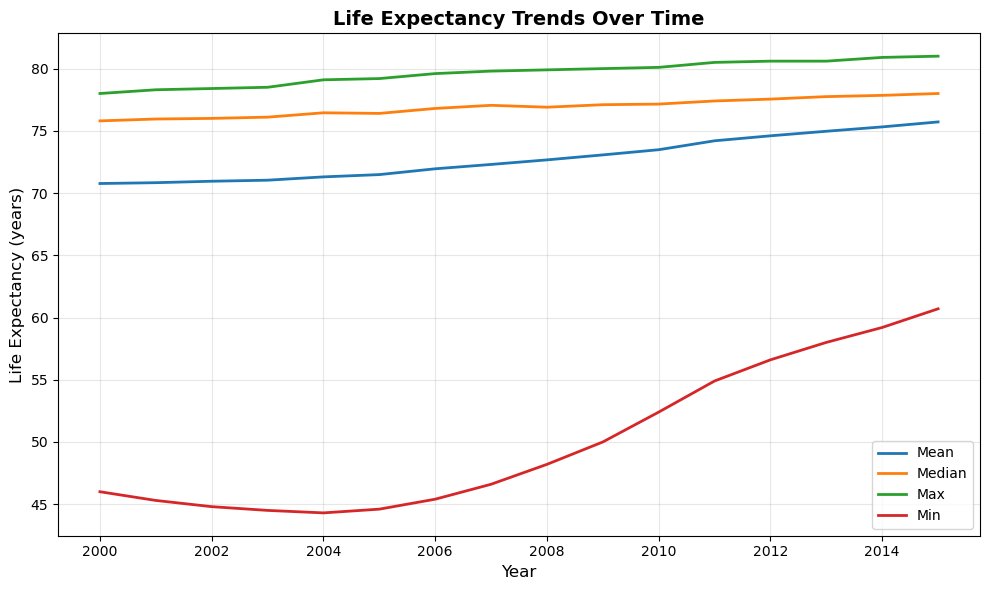

4.950000000000003
Year
2000         NaN
2001    0.066667
2002    0.116667
2003    0.083333
2004    0.266667
2005    0.183333
2006    0.466667
2007    0.350000
2008    0.366667
2009    0.400000
2010    0.416667
2011    0.716667
2012    0.400000
2013    0.366667
2014    0.350000
2015    0.400000
Name: Life expectancy at birth (years), dtype: float64


In [ ]:
# Show year life expectancy in line plot

import matplotlib.pyplot as plt

def plot_life_expectancy_trends(df, column_name="Life expectancy at birth (years)", 
                               figsize=(10, 6),
                               marks_dots=True):
    """
    Plot life expectancy trends over years showing mean, median, max, and min values.
    
    Parameters:
    df (DataFrame): The dataframe containing the data
    column_name (str): The name of the life expectancy column
    figsize (tuple): Figure size for the plot
    marks_dots (bool): Whether to mark data points with dots
    """
    # Group data by year and calculate statistics in one operation
    yearly_stats = df.groupby('Year')[column_name].agg(['mean', 'median', 'max', 'min'])
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Plot all statistics
    yearly_stats['mean'].plot(label='Mean', linewidth=2, color='blue')
    yearly_stats['median'].plot(label='Median', linewidth=2, color='green')
    yearly_stats['max'].plot(label='Max', linewidth=2, color='red')
    yearly_stats['min'].plot(label='Min', linewidth=2, color='orange')
    # add points to the plot
    plt.scatter(yearly_stats.index, yearly_stats['mean'], color='blue', s=50, zorder=5)
    if marks_dots:
        for x, y in zip(yearly_stats.index, yearly_stats['mean']):
            plt.text(x, y, f'{y:.2f}', va='bottom', ha='left')
    plt.scatter(yearly_stats.index, yearly_stats['median'], color='green', s=50, zorder=5)
    plt.scatter(yearly_stats.index, yearly_stats['max'], color='red', s=50, zorder=5)
    plt.scatter(yearly_stats.index, yearly_stats['min'], color='orange', s=50, zorder=5)
    
    # Customize the plot
    plt.xlabel("Year", fontsize=12)
    plt.ylabel(column_name, fontsize=12)
    plt.title(f"{column_name} Trends Over Time", fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Call the function
plot_life_expectancy_trends(df)
plot_life_expectancy_trends(df, column_name="GDP", figsize=(12, 8), marks_dots=False)
avg_life_expect_velocity = df.groupby('Year')['Life expectancy at birth (years)'].mean().diff()
last_year_minus_first_year = df.groupby('Year')['Life expectancy at birth (years)'].mean().iloc[-1] - df.groupby('Year')['Life expectancy at birth (years)'].mean().iloc[0]
print(last_year_minus_first_year)
print(avg_life_expect_velocity)

<Axes: >

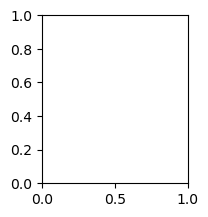

In [53]:
fig = plt.figure()

fig.add_subplot(231)

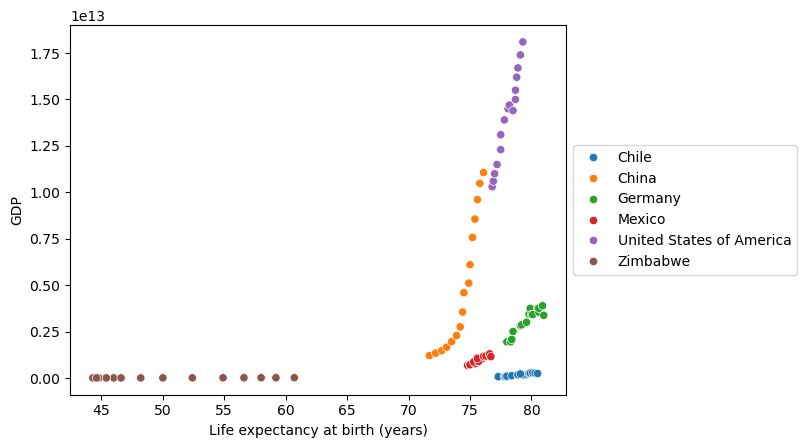

In [81]:
sns.scatterplot(data = df, x='Life expectancy at birth (years)', y = "GDP", hue=df.Country).legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1);

2. Correlation between life expectancy and GDP

<Figure size 640x480 with 0 Axes>

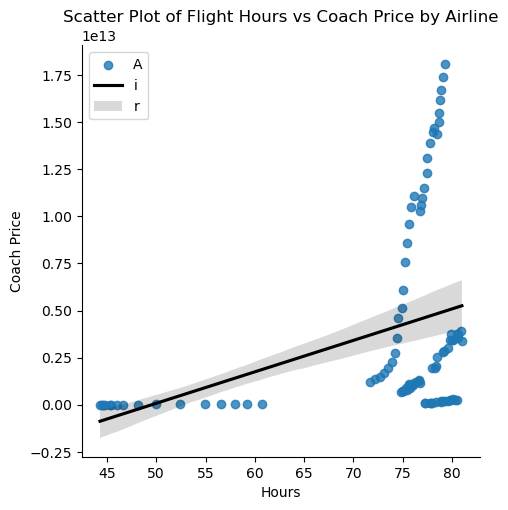

<Figure size 640x480 with 0 Axes>

In [78]:
import seaborn as sns
perc = 1
sample = df.sample(n = int(df.shape[0]*perc))
plt.figure()
#plt.figaspect(0.5)
sns.lmplot(x = 'Life expectancy at birth (years)', y = "GDP", data = sample, line_kws={'color': 'black'}, lowess=False)
plt.title('Scatter Plot of Flight Hours vs Coach Price by Airline')
plt.xlabel('Hours')
plt.ylabel('Coach Price')
plt.legend('Airline')
plt.show()
plt.clf()


<Figure size 1000x600 with 0 Axes>

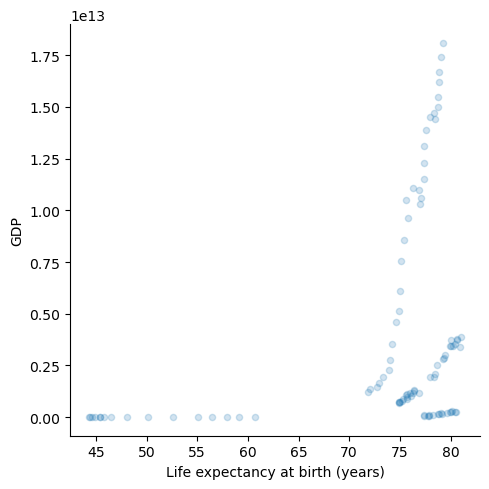

In [79]:
plt.figure(figsize=(10, 6))

sns.lmplot(data=sample, x='Life expectancy at birth (years)', y='GDP',x_jitter=0.2, y_jitter=0.2,fit_reg = False,scatter_kws={"s": 20, "alpha":0.2})

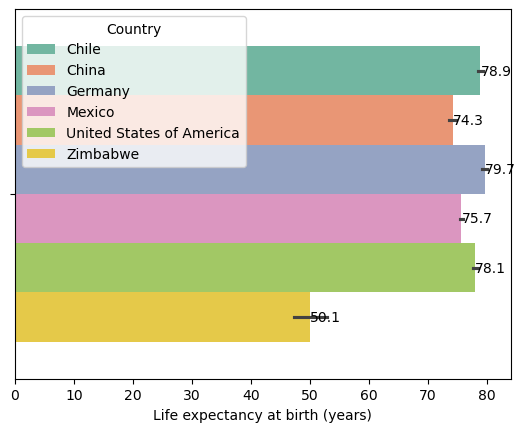

In [88]:
ax = sns.barplot(data = df, x="Life expectancy at birth (years)",hue="Country",palette="Set2")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=10, rotation=0)

In [90]:
dfMeans = df.drop("Year", axis = 1).groupby("Country").mean().reset_index()
dfMeans

,Country,Life expectancy at birth (years),GDP
0,Chile,78.94375,1.697888e+11
1,China,74.26250,4.957714e+12
2,Germany,79.65625,3.094776e+12
3,Mexico,75.71875,9.766506e+11
4,United States of America,78.06250,1.407500e+13
5,Zimbabwe,50.09375,9.062580e+09


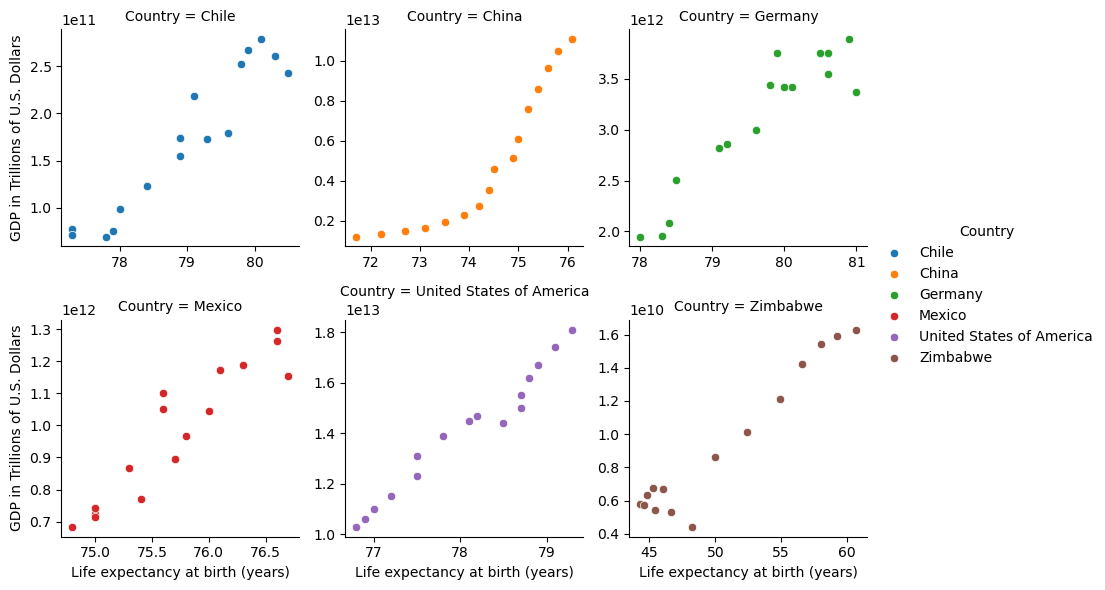

In [91]:
graph = sns.FacetGrid(df, col="Country", col_wrap=3,
                      hue = "Country", sharey = False, sharex = False)
graph = (graph.map(sns.scatterplot,"Life expectancy at birth (years)", "GDP")
         .add_legend()
         .set_axis_labels("Life expectancy at birth (years)", "GDP in Trillions of U.S. Dollars"));

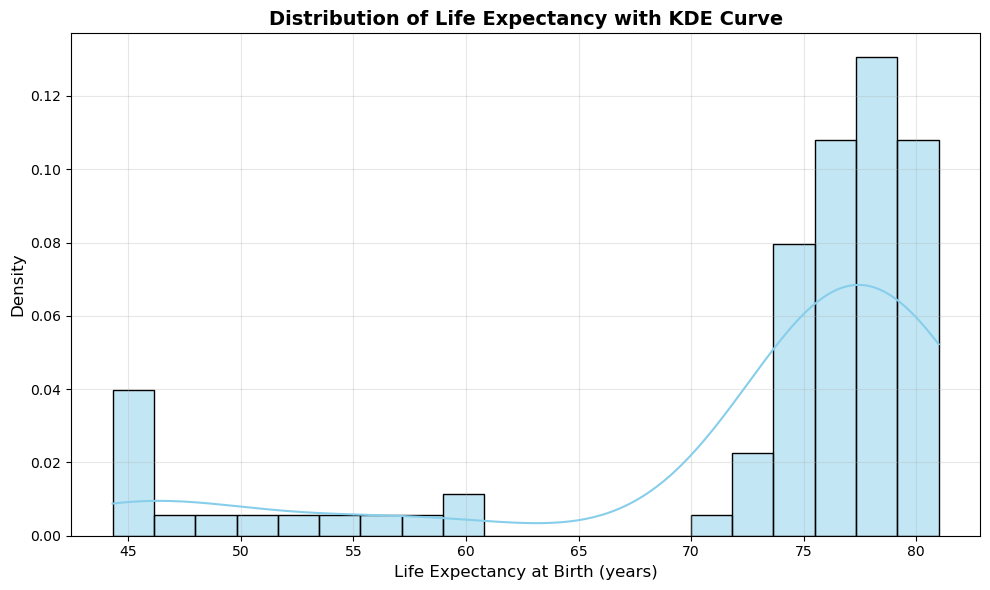

In [98]:
# Distribution of life expectancy with KDE curve
plt.figure(figsize=(10, 6))

# Method 1: Using seaborn histplot with KDE
sns.histplot(data=df, x="Life expectancy at birth (years)", bins=20, 
             color='skyblue', edgecolor='black', kde=True, stat='density')

plt.title("Distribution of Life Expectancy with KDE Curve", fontsize=14, fontweight='bold')
plt.xlabel("Life Expectancy at Birth (years)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()